In [40]:
import sys
sys.path.append('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/')
from pathlib import Path
from meteofetch import Arome0025
import get_meteo_dataset
import generate_maps

%load_ext autoreload
%autoreload 2

In [42]:
datasets = get_meteo_dataset.get_latest_forecast(
    'IP1', 
    Path('/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs'),
    fields=['u', 'v'])


Files already up-to-date: ['/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__00H06H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__07H12H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__13H18H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__19H24H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__25H30H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__31H36H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france/gribs/arome__0025__IP1__37H42H__2026-05-09T09-00-00Z.grib2', '/Users/qubo/L

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


In [71]:
da_v = datasets["v"]  # Temperature at 2 meters
da_u = datasets["u"]  # Temperature at 2 meters


layer_u = da_u.isel(time=0).sel(isobaricInhPa=800)
layer_v = da_v.isel(time=0).sel(isobaricInhPa=800)
layer_u

<xarray.DataArray 'u' (latitude: 717, longitude: 1121)> Size: 3MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(717, 1121), dtype=float32)
Coordinates:
  * latitude       (latitude) float64 6kB 37.5 37.53 37.55 ... 55.35 55.38 55.4
  * longitude      (longitude) float64 9kB -12.0 -11.97 -11.95 ... 15.98 16.0
    step           timedelta64[ns] 8B 00:00:00
    isobaricInhPa  float64 8B 800.0
    time           datetime64[ns] 8B 2026-05-09T09:00:00
    spatial_ref    int64 8B 0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      803757
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind
    Packaged by:                              meteofetch

/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/qubo/miniconda3/envs/meteo/lib/python3.14/site-packages/shapely/creation.py:730: Runt

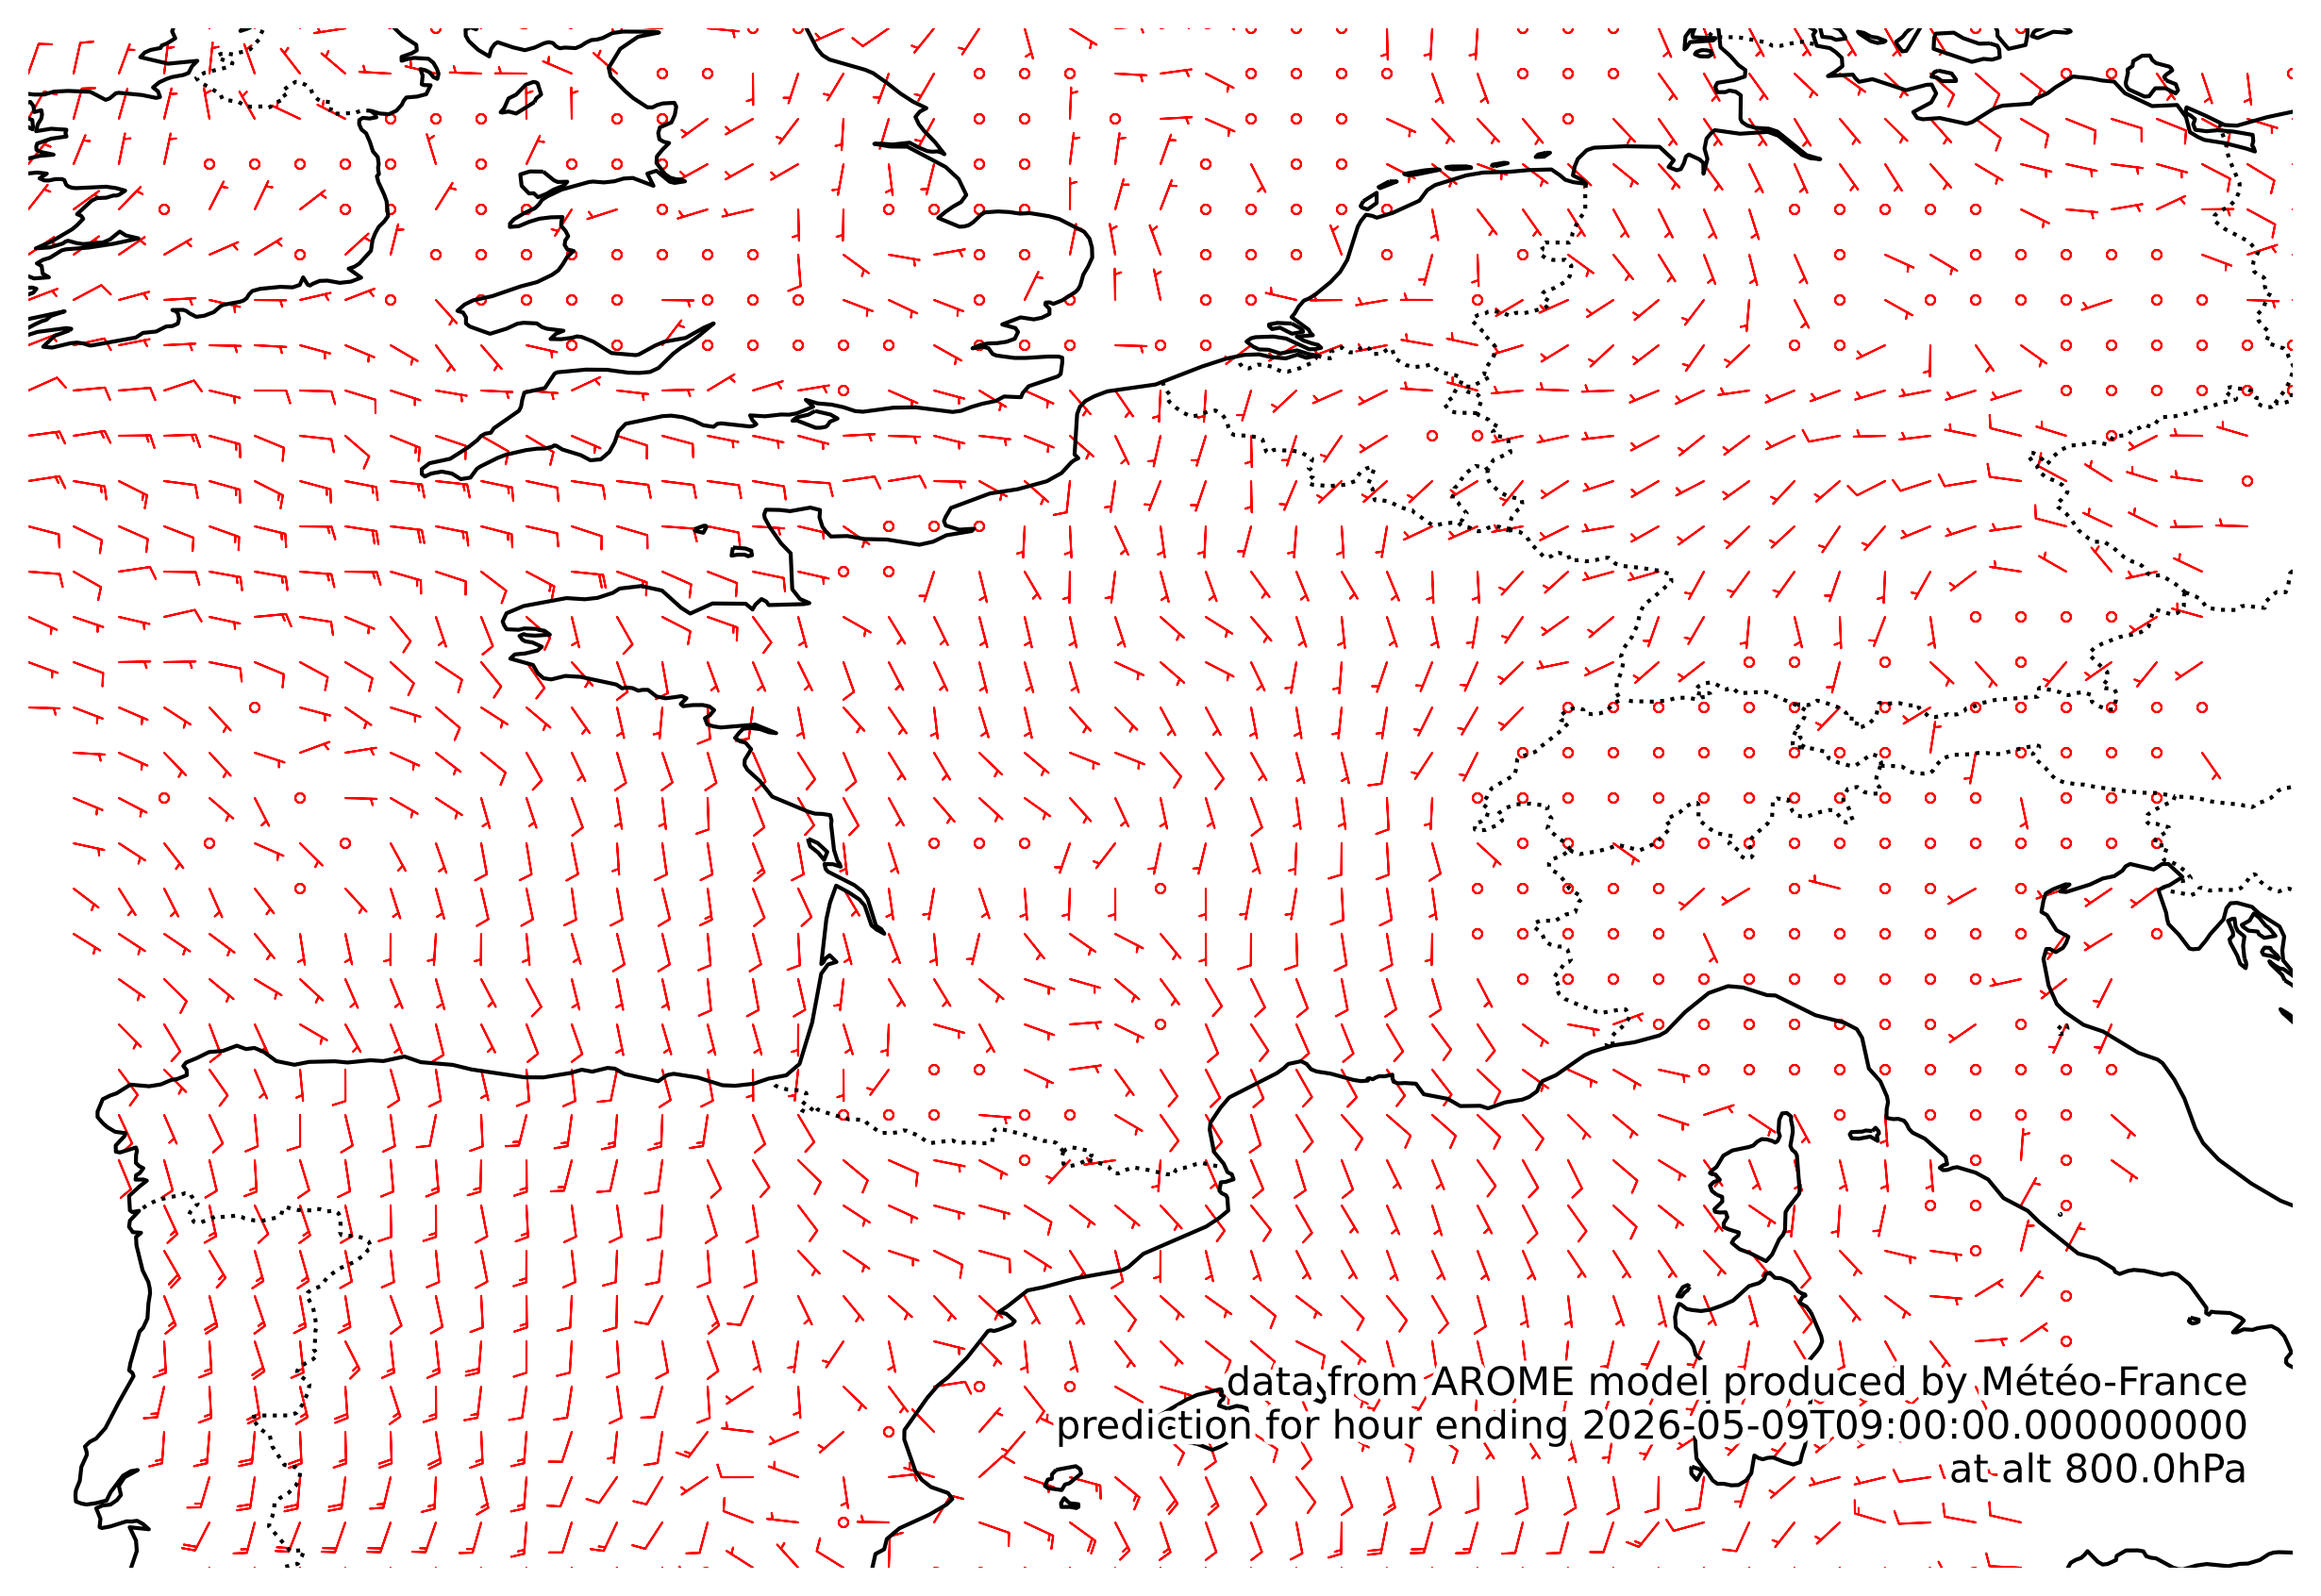

In [74]:
generate_maps.plot_wind_barbs_to_png(
    layer_u,
    layer_v,
    output_path=Path("/Users/qubo/Library/CloudStorage/SynologyDrive-auto-sync/labs/meteo_france//wind_barbs.png"),
    subsample=20,  # Plot every 10th point
    barb_color="red",
    barb_length=4.0,
    show=True
)
